In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import itertools



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from lmfit import Model
import qutip as qp
from typing import List
from pathlib import Path
import _pickle as cPickle
from tensor_networks_simulations.general_tools.plot_tools import figure_styling, trim_axs
figure_styling()
import seaborn as sns

In [5]:
from lmfit.models import PolynomialModel
def polynomial(y_in: List, scale_list: List):
    model = PolynomialModel(2)
    params = model.guess(y_in, x=scale_list)
    #z = np.polyfit(scaling_list, y_in, (order-1))
    result = model.fit(data=y_in, params=params, x=scale_list)
    #print(result.fit_report())
    return result

In [6]:
#         for k in range(0, len(y)):
#             product = 1
#             for i in range(0, len(y)):
#                 if k != i:
#                     product = product * (scaling[i]/(scaling[k]-scaling[i]))
#             mitigated = mitigated + y[k]*product


def richardson(y_in: List, scale_list: List):    
    mitigated = 0
    for k in range(len(y_in)):
        product = 1
        for i in range(len(y_in)):
            if i != k:
                product = product * (scale_list[i]/(scale_list[i]-scale_list[k]))
        mitigated = mitigated + y_in[k]*product
    return mitigated

def polyexp():
    pass

In [7]:
from lmfit import Model

In [10]:
path=Path(os.getcwd()).parent
path_bf = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_bit_flip/")
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing") 
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_2nd_DQPT_integrable") 
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_1st_DQPT_nonintegrable") 

In [11]:
model = "TFIChain"
dt = 0.005
t_f = 8
scale = 1
total_steps = int(t_f/(scale*dt))
L = 32
chi_max = 200
path = path_dep
#cPickle_off = open(Path('data_L10_chi32')/f'mxs_{model}_L-{L}_chi-{chi_max}_scale-{1}_gamma-{0}.pickle', "rb")
cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mxs_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_mx0 = dta

cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mzs_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_mz0 = dta


cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'czz_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_czz = dta


cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'rate_f_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_ratef = dta

data_mx0

ts0 = 0.1*np.arange(0, len(dta))

len(dta), len(ts0)
print(ts0, dta)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3
 5.4 5.5 5.6 5.7 5.8 5.9 6.  6.1 6.2 6.3 6.4 6.5 6.6 6.7 6.8 6.9 7.  7.1
 7.2 7.3 7.4 7.5 7.6 7.7 7.8 7.9 8. ] [6.245004513516568e-16, 0.009688306101406285, 0.03875171448571096, 0.08712897855239717, 0.15446563117690537, 0.23964104989423607, 0.34000396136476607, 0.45049405279391175, 0.563527511245349, 0.6707978371496593, 0.7663606801937733, 0.8482238847239522, 0.9174045509225487, 0.9764007924880851, 1.0287642637758534, 1.0772772533364734, 1.1238153625556482, 1.1699308421997623, 1.2066477051266502, 1.1426687424305433, 0.9691135951989426, 0.8091239520008588, 0.6683915960091209, 0.5447176886154145, 0.4381669140117684, 0.3481731250280778, 0.2738524114290068, 0.21430760888472308, 0.16847023084583998, 0.13510321589277377, 0.11277845805858679, 0.09988008780920775, 0.094733085196

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt

from colorsys import hls_to_rgb

def rainbow_color_stops(n=10, end=2/3):
    return [ hls_to_rgb(end * i/(n-1), 0.5, 1) for i in range(n) ]

colors = rainbow_color_stops(10)
colors

[(1.0, 0.0, 0.0),
 (1.0, 0.4444444444444444, 0.0),
 (1.0, 0.8888888888888888, 0.0),
 (0.6666666666666663, 1.0, 0.0),
 (0.22222222222222254, 1.0, 0.0),
 (0.0, 1.0, 0.2222222222222222),
 (0.0, 1.0, 0.6666666666666666),
 (0.0, 0.8888888888888888, 1.0),
 (0.0, 0.4444444444444444, 1.0),
 (0.0, 0.0, 1.0)]

In [13]:
import random
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))
print(get_colors(5))

markers = itertools.cycle(('o','s' ,'d', 'P', 'X', 'D', 'v', '<', '>', '^')) 
color= ['#1f77b4',
          '#ff7f0e',
          '#2ca02c',
          '#d62728',
          '#9467bd',
          '#8c564b',
          '#e377c2',
          '#7f7f7f',
          '#bcbd22',
          '#17becf',
          '#1a55FF']


['#ca4f72', '#5021b1', '#de1e67', '#1b051d', '#0c0b51']


In [14]:
data = {}
#scale_list = [1.0, 1.25, 1.5, 1.75, 2]#, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]
scale_list = [1.0, 1.5, 2.0, 2.5, 3.0,3.5, 4.0]#, 1.5,  2.0, 2.5, 3.0, 3.5, 4.0]#, 2.0, 2.5, 3.0, 3.5, 4.0]
#scale_list = [0.25, 0.5, 0.75, 1.0]
gamma_list = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
#gamma_list = [0.001, 0.005, 0.01, 0.02, 0.05]#[0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05, 0.1, 0.25, 0.5]#[0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.01, 0.05, 0.1, 0.25, 0.5]
#gamma_list = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]
len_gamma = len(gamma_list)
colors = get_colors(len_gamma)
colors = sns.color_palette(n_colors=len_gamma, palette="deep")[::-1]
colors

[(0.8, 0.7254901960784313, 0.4549019607843137),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.333333333333333

In [25]:




yout_richadson_mx = {}
yout_richadson_mz = {}
yout_richadson_czz = {}
yout_richadson_ratef = {}
mx_in = {}
mz_in = {}
czz_in = {}
cz1_in = {}
cz2_in={}
ratef_in = {}
ts = {}
data_richardson_mx = {}
data_richardson_mz = {}
data_richardson_czz = {}
data_richardson_ratef = {}
tmp_data = {}
tss = {}

for i, gamma in enumerate(gamma_list):
    for scale in scale_list:
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mxs_scale-{scale}_gamma-{gamma}.pickle', "rb")
        mx_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mzs_scale-{scale}_gamma-{gamma}.pickle', "rb")
        mz_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)
        #print(len(mx_in[f"gamma={gamma}_scale={scale}"]), scale, gamma)
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'ts_scale-{scale}_gamma-{gamma}.pickle', "rb")
        ts[f"ts_gamma{gamma}_scale{scale}"] = np.array(cPickle.load(cPickle_off))
        tss[f"ts_gamma{gamma}_scale{scale}"] = ts[f"ts_gamma{gamma}_scale{scale}"]/scale
        
        
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'czz_scale-{scale}_gamma-{gamma}.pickle', "rb")
        czz_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)
        #print(len(czz_in[f"gamma={gamma}_scale={scale}"]), gamma, scale)
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'czz1_scale-{scale}_gamma-{gamma}.pickle', "rb")
        cz1_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off) 
        
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'czz2_scale-{scale}_gamma-{gamma}.pickle', "rb")
        cz2_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)        
        
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'rate_f_scale-{scale}_gamma-{gamma}.pickle', "rb")
        ratef_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)        

print("------------------")
        
#for scale in scale_list:    
for gamma in gamma_list:
        yout_richadson_mx[f"{gamma}"] = []
        yout_richadson_mz[f"{gamma}"] = []
        yout_richadson_czz[f"{gamma}"] = []
        yout_richadson_ratef[f"{gamma}"] = []
        #print(gamma)
        for i in range(len(tss[f"ts_gamma{gamma}_scale{2.0}"])):
            
            data_richardson_mx[f"gamma_{gamma}_{i}"] = [mx_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            data_richardson_mz[f"gamma_{gamma}_{i}"] = [mz_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            data_richardson_czz[f"gamma_{gamma}_{i}"] = [czz_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            data_richardson_ratef[f"gamma_{gamma}_{i}"] = [ratef_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            #print(data_richardson[f"gamma_{gamma}_{i}"], gamma)

            yout_richadson_mx[f"{gamma}"].append(richardson(data_richardson_mx[f"gamma_{gamma}_{i}"], scale_list))
            yout_richadson_mz[f"{gamma}"].append(richardson(data_richardson_mz[f"gamma_{gamma}_{i}"], scale_list))
            yout_richadson_czz[f"{gamma}"].append(richardson(data_richardson_czz[f"gamma_{gamma}_{i}"], scale_list))
            yout_richadson_ratef[f"{gamma}"].append(richardson(data_richardson_ratef[f"gamma_{gamma}_{i}"], scale_list))
            #print(yout_richadson[f"{gamma}"][-1])


   
    
    
    


------------------


In [19]:
#fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,8))
color_cycle = plt.rcParams['axes.prop_cycle']()


9
3 3


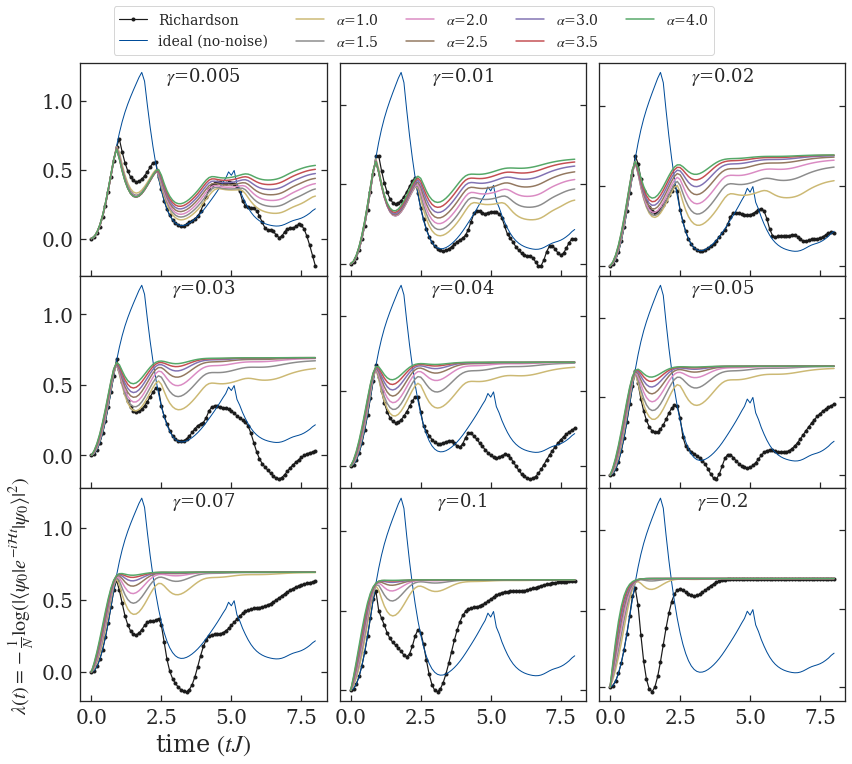

In [31]:
import seaborn as sns
sns.set_theme(style="ticks",)

figure_styling()
data = {}
scale_list = [1.0, 1.5, 2.0,  2.5, 3.0,  3.5,  4.0]
gamma_list = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.2]
print(len(gamma_list))
nrows = 3
ncols = int(len(gamma_list)/nrows)+1
ncols = 3
print(nrows, ncols)

#plt.style.use('classic')



text="abcdefghijklmnopqrstuvwxyz"
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,10), constrained_layout=False)
m=0

for i, gamma in enumerate(gamma_list):
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        if g:
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mx[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_czz[f"{gamma}"], marker="o", ms=3, color = "k",label="Richardson" )
            line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_ratef[f"{gamma}"], marker="o", ms=3, color = "k",label="Richardson" )
            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"],marker="o", ms=3, color = "k",label="richardson" )
            #line_nonoise = ax[m][n].plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal (no-noise)")
            #line_nonoise = ax[m][n].plot(ts0, data_czz, lw = 1, color = '#004C99',label="ideal (no-noise)")
            line_nonoise = ax[m][n].plot(ts0, data_ratef, lw = 1, color = '#004C99',label="ideal (no-noise)")
            #ax[m][n].plot(ts0, data_mz0, color="#8A2BE2",label="ideal")
            ax[m][n].set_title(fr"$\gamma$={gamma}")
            ax[m][n].tick_params(axis='both', direction="in", which='major', labelsize=20)
            ax[m][n].tick_params(axis='both', which='minor', labelsize=12)
            tex = text[i]
            #ax[m][n].text(7., 0.4, "("+tex + ")", fontsize=20)
            g=False
        #line = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        line = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], marker = "", ms=1, label=fr"$\alpha$={scale}")
        ax[m][n].set_title(fr"$\gamma$={gamma}", fontsize=18,  y=1.0, pad=-18)
        #ax[m][n].set_ylim(0.2,1)
        if n!=0:
            #pass
            #ax[m][n].axes.yaxis.set_visible(False)
            ax[m][n].axes.yaxis.set_ticklabels([])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False,labelleft=True )
        if m != 2:
            #ax[m][n].axes.xaxis.set_visible(False)
            ax[m][n].axes.xaxis.set_ticklabels([])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False, labelleft=True)
    #ax[m][n].tick_params(labeltop=True, labelright=True)
    ax[m][n].tick_params(which='both', bottom=True, right=True, top=False, labelbottom=True) 
            #pass
#for i in range(6):
#    ax[2][i].set_xticks(range(0,9,2))
#ax[0][0].set_ylim(0.2,0.4)
ax[2][0].set_xlabel(fr"time $(tJ)$", fontsize=24)
#ax[2][0].set_ylabel(r"$\langle \sigma^z_{\frac{L}{2}} \sigma^z_{\frac{L}{2}+1}\rangle(\alpha t)$", fontsize=24)
ax[2][0].set_ylabel(r"$\lambda(t) = -\frac{1}{N}\log(|\langle \psi_0| e^{-i\mathcal{H}t} |\psi_0 \rangle|^2)$", fontsize=20)

lines, labels = ax[2][0].get_legend_handles_labels()
    
#fig.legend(lines, labels, loc = (0.1,0.91), ncol=5,fontsize=12, frameon=False)
leg = fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.13,0.07,1,1), shadow=False, ncol=5,fontsize=14,frameon=True)


ax = trim_axs(ax, len(gamma_list))

plt.tight_layout(h_pad=0, )
plt.plot()
plt.savefig(f"plot_depolarizing_nonintegrable_ratef_{L}_chi_{chi_max}.png", bbox_extra_artists=(leg,), bbox_inches='tight')

In [21]:
import os
print(os.getcwd())

/home/younes/Documents/repos/tensor_networks_Hannover/Tensor_Networks_Simulations/jupyter-notebooks


9
3 4


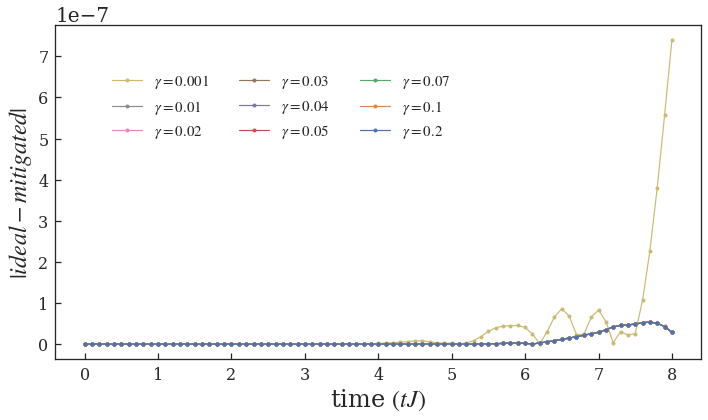

In [22]:
import seaborn as sns
sns.set_theme(style="ticks",)

figure_styling()
data = {}
#scale_list = [1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]
#gamma_list = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.01, 0.05, 0.1, 0.25, 0.5]
print(len(gamma_list))
nrows = 3
ncols = int(len(gamma_list)/nrows)+1
print(nrows, ncols)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,6), constrained_layout=False)
m=0

for i, gamma in enumerate(gamma_list):
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
   

        
    #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mx[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
    ax.plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),np.abs(np.array(data_mz0)-yout_richadson_mz[f"{gamma}"]), marker="o", ms=3, color = colors[i],label=f"$\gamma = {gamma}$" )
    #ax.set_yscale("semilog")
    #line_nonoise = ax[m][n].plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal (no-noise)")
    #ax[m][n].plot(ts0, data_mz0, label="ideal")
    #ax.set_title(fr"$\gamma$={gamma}")
    ax.tick_params(axis='both', direction="in", which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=8)
    g=False
    #line = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
    #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), marker = "", ms=1, label=fr"$\alpha$={scale}")
    #ax.set_title(fr"$\gamma$={gamma}", fontsize=18,  y=1.0, pad=-18)
    #ax[m][n].set_ylim(0.2,1)
    if n!=0:
        pass
        #ax[m][n].axes.yaxis.set_visible(False)
    if m != 2:
        #ax.axes.xaxis.set_visible(False)
            pass
#for i in range(6):
#    ax[2][i].set_xticks(range(0,9,2))
#ax[0][0].set_ylim(0.2,0.4)
ax.set_xlabel(fr"time $(tJ)$", fontsize=24)
ax.set_ylabel(fr"$| ideal-mitigated |$", fontsize=24)

lines, labels = ax.get_legend_handles_labels()
    
fig.legend(lines, labels, loc = (0.15,0.65), ncol=3,frameon=0,fontsize=15)



#ax = trim_axs(ax, len(gamma_list))

plt.tight_layout(h_pad=0, )
plt.savefig(f"plot_error_depolarize_sz_{L}_chi_{chi_max}.png")

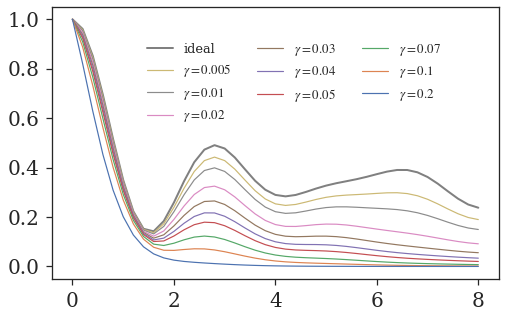

In [17]:
scale = 1.0
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,5))
line_nonoise = ax.plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal")
for j, gamma in enumerate(gamma_list):
    
    ax.plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], label=f"$\gamma={gamma}$")
plt.legend(loc=(0.2,0.55), ncol=3, fontsize=13, frameon=0)

In [18]:
def jpp(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    print([[np.abs(a - i).argmin()] for i in b])
    return [b[np.abs(a - i).argmin()] for i in b]

def jpp2(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    print(np.argmin(np.abs(np.subtract.outer(a, b)), axis=0))
    return a[np.argmin(np.abs(np.subtract.outer(a, b)), axis=0)]

In [19]:
def lower_bound(sequence, value, compare):
    elements = len(sequence)
    offset = 0
    middle = 0
    found = len(sequence)

    while elements > 0:
        middle = elements >> 1
        if compare(value, sequence[offset + middle]) > 0:
            offset = offset + middle + 1
            elements = elements - (middle + 1)
        else:
            found = offset + middle
            elements = middle
    return found

In [20]:
# in_tss={}
# indices={}
# y_in_picked = {}

# for gamma in gamma_list:
#     for scale in scale_list:
#         #old_interval = [tss[f"ts_gamma{gamma}_scale{scale}"][0], tss[f"ts_gamma{gamma}_scale{scale}"][-1]]
#         #new_interavel = [0.0, 8.0]
#         #old_value = tss[f"ts_gamma{gamma}_scale{scale}"][-1]
#         #new_values = [np.interp(old_value, old_interval, new_interavel) for old_value in tss[f"ts_gamma{gamma}_scale{scale}"] ]
        
        
#         b = tss[f"ts_gamma{gamma}_scale{1}"]
#         a = tss[f"ts_gamma{gamma}_scale{scale}"]
#         re_a = a[::-1]

#         in_tss[f"ts_gamma{gamma}_scale{scale}"] = [min([a[lower_bound(a, i, lambda x,y: x > y) % len(a)], re_a[lower_bound(re_a, i, lambda x, y: x < y) % len(re_a)]], key=lambda num:abs(num-i)) for i in b]
#         aa = in_tss[f"ts_gamma{gamma}_scale{scale}"]
#         indices[f"ts_gamma{gamma}_scale{scale}"] = [list(a).index(i) for i in aa]
#         y_in_picked[f"gamma={gamma}_scale={scale}"] = [y_in[f"gamma={gamma}_scale={scale}"][i] for i in [list(a).index(i) for i in aa]]
        
        
#         #print(len(aa), indices[f"ts_gamma{gamma}_scale{scale}"])

In [21]:
# y_out_richadson = {}
# y_out_poly_eval = {}
# for gamma in gamma_list:
    
#     y_out_richadson[f"gamma_{gamma}"] = []
#     y_out_poly_eval[f"gamma_{gamma}"] = []
#     for i in range(len(in_tss[f"ts_gamma{gamma}_scale{scale}"])):
#         tmp_data_richardson = []
#         tmplist = []
#         scale_int = []
#         for scale in scale_list:
#             tmplist.append(y_in_picked[f"gamma={gamma}_scale={scale}"][i])
#             if np.mod(scale, 1) == 0:
#                 scale_int.append(scale)
#                 tmp_data_richardson.append(y_in_picked[f"gamma={gamma}_scale={scale}"][i])
        

#         y_out_richadson[f"gamma_{gamma}"].append(richardson(tmp_data_richardson, scale_int))
#         y_out_poly= polynomial(tmplist, scale_list)
    
#         print("richardson", y_in_picked[f"gamma={gamma}_scale={4.0}"][i],richardson(tmp_data_richardson, scale_int), in_tss[f"ts_gamma{gamma}_scale{scale}"][i],gamma)
#         #print("polynomial", y_out_poly.best_fit)
#         y_out_poly_eval[f"gamma_{gamma}"] = y_out_poly.eval(x=np.arange(-0.0, 5.01, 0.01), params=y_out_poly.params)
# #y_out_poly_eval

In [22]:
# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,5))
# for i, gamma in enumerate(gamma_list):
#     if gamma == 0.05:
#         print(y_out_richadson[f"gamma_{gamma}"])
#         ax.plot(in_tss[f"ts_gamma{gamma}_scale{scale}"], y_out_richadson[f"gamma_{gamma}"], color=colors[i],ls="-",lw=0.5,marker="o" ,ms=1, mfc="none",label=f"$\gamma={gamma}$")
#         for scale in scale_int:
#             #print(gamma, scale)
#             if scale==4:
#                 print("--------------------")
#                 print(y_in_picked[f"gamma={gamma}_scale={scale}"])
#             ax.plot(in_tss[f"ts_gamma{gamma}_scale{scale}"], y_in_picked[f"gamma={gamma}_scale={scale}"], "-" , label=fr"$\alpha$={scale}")

# ax.plot(ts0, data_0, color="k",lw= 2.5, label="free")           
# plt.legend(loc=(1.04,0),ncol=2, fontsize=15)

In [23]:
rich_list = {}
for j, gamma in enumerate(gamma_list):
    rich_list[f"gamma={gamma}"] = []
    for i, t in enumerate(tss[f"ts_gamma{gamma}_scale{1.0}"]):
    
        dta = np.array([mx_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_int ])
        rich = richardson(dta, scale_int)
        rich_list[f"gamma={gamma}"].append(rich)
        #print(dta, "-->",rich, gamma, t)
    #print("---------")

NameError: name 'scale_int' is not defined

In [ ]:
import seaborn as sns
sns.set_theme(style="ticks")

figure_styling()
data = {}
#scale_list = [1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]
#gamma_list = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.01, 0.05, 0.1, 0.25, 0.5]
print(len(gamma_list))
nrows = 3
ncols = int(len(gamma_list)/nrows)#+1
print(nrows, ncols)

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20,10))
m=0
for i, gamma in enumerate(gamma_list):
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        if g:
            ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),rich_list[f"gamma={gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            ax[m][n].plot(ts0, data_0, label="no noise")
            ax[m][n].set_title(fr"$\gamma$={gamma}")
            
            
            g=False
        ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), marker = "o", ms=1, label=fr"$\alpha$={scale}")
        
        ax[m][n].set_title(fr"$\gamma$={gamma}")
        ax[m][n].set_ylim(0.2,1)
        if n!=0:
            
            ax[m][n].axes.yaxis.set_visible(False)
        if m != 2:
            ax[m][n].axes.xaxis.set_visible(False)

for i in range(6):
    ax[2][i].set_xticks(range(0,9,2))

ax[2][0].set_xlabel(fr"time $(tJ)$", fontsize=20)
ax[2][0].set_ylabel(fr"$<S^x>(\alpha t_{{f}})$", fontsize=20)

plt.legend(loc =(-7.15, 1.7),ncol=1, frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(f"plot_{L}_chi_{chi_max}.pdf")

In [ ]:
N_qubits = 4
for ii in range(0, N_qubits):
    nf_conf = np.array([int(i) for i in bin(ii)[2:].zfill(N_qubits)])
    
    print(bin(ii)[2:].zfill(N_qubits))
    nf_str = bin(ii)[2:].zfill(N_qubits)#" ".join(str(x) for x in nf_conf)
    print(nf_conf, nf_str, type(nf_str))

In [ ]:
final_time = 8
scale = 2.25 
dt = 0.005
total_steps = int(final_time/(scale*dt))
print(total_steps)
j = 0
for i in range(total_steps+1):
    if np.mod(i, int(20/scale)) ==0:
        j+=1
        #print(j, i, f"{scale*dt*(i+1):.4f}")

In [ ]:
path = Path("/home/younes/Documents/repos/tensor_networks_Hannover/Tensor_Networks_Simulations/jupyter-notebooks/data_cluster/")

In [ ]:
L = 32
chi_list = [100, 200]
scale =1.0
gamma = 0.005
dat={}
fig, ax = plt.subplots(nrows=1,ncols=1, figsize=(7,6))
for chi in chi_list:
    cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi}'/f'mxs_scale-{scale}_gamma-{gamma}.pickle', "rb")
    dta = cPickle.load(cPickle_off)
    cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi}'/f'ts_scale-{scale}_gamma-{gamma}.pickle', "rb")
    tdta = cPickle.load(cPickle_off)
    print(len(dta), chi)
    ax.plot(tdta, dta, label=f"chi={chi}")
plt.legend()

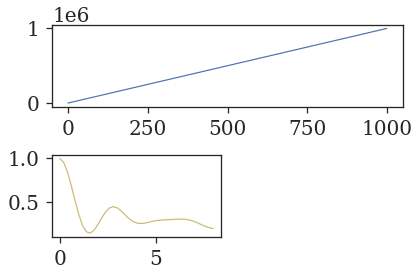

In [38]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(tight_layout=True)
ax = fig.add_subplot(gs[0, :])
ax.plot(np.arange(0, 1e6, 1000))
gs = gridspec.GridSpec(ncols=2, nrows=2)
ax = fig.add_subplot(gs[1, i])
ax.plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], label=f"$\gamma={gamma}$")